#### python -m venv "myenv"
#### myenv/Scripts/activate
#### pip install -r requirements.txt


In [2]:
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers
# from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

## Configurations

In [3]:
train_dir = r"dataset\FYP_Datasets\train"
test_dir = r"dataset\FYP_Datasets\test"
val_dir = r"dataset\FYP_Datasets\validation"

BATCH_SIZE = 32
IMG_SIZE = (150, 150)

## Prepare Dataset
### image_dataset_from_directory() >> function to built ready tf.data.Dataset to train 
### label encoding, shuffle and split and ...... 

In [4]:
train_dataset = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_dataset = keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names
print("Class names:", class_names)

Found 3043 files belonging to 6 classes.
Found 1500 files belonging to 6 classes.
Found 1500 files belonging to 6 classes.
Class names: ['Emerald', 'Fake_Emerald', 'Fake_Ruby', 'Fake_Turquoise', 'Ruby', 'Turquoise']


## CNN Model

In [5]:
def create_cnn_model():
    inputs = keras.Input(shape=(150, 150, 3))

    # Rescaling pixel values
    x = layers.Rescaling(1./255)(inputs)  # Normalize pixel values from [0,255] to [0, 1]

    # Convolutional Block 1

    # Apply 32 filters of size 3x3 to detect simple features (edges, lines)
    # 'same' padding keeps the image size the same after convolution
    # ReLU activation introduces non-linearity, allowing the model to learn complex patterns
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)

    # Reduce image size by half (downsampling)
    # Keeps important features and reduces computation
    x = layers.MaxPooling2D()(x)

    # Convolutional Block 2
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    # Convolutional Block 3
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    # Convolutional Block 4
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    # Global Average Pooling
    # Convert feature maps into a single vector
    # Takes the average of each feature map
    # Reduces overfitting compared to Flatten
    x = layers.GlobalAveragePooling2D()(x)  #(256,) instead of (256*9*9) with Flatten)
    # x = layers.Flatten()(x)

    # Dropout
    # Randomly drop 25% of neurons during training
    # Helps prevent overfitting
    x = layers.Dropout(0.25)(x)


    # Fully connected layer
    # Learns complex combinations of extracted features
    x = layers.Dense(512, activation="relu")(x)

    # Output Layer
    # 6 neurons = 6 classes
    # Softmax converts outputs to probabilities that sum to 1
    outputs = layers.Dense(6, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    # Adam: optimizer for updating weights
    # sparse_categorical_crossentropy: for integer multi-class labels
    # accuracy: evaluation metric
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### Perform Training

In [ ]:
print("\n--- Training Model from scratch ---")



model_save_path = "models/cnn_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=model_save_path,
        save_best_only=True,
        monitor="val_loss"
    ),
     keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5
    )
]

model_scratch = create_cnn_model()
history_scratch = model_scratch.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=callbacks,
    verbose=2
)



--- Training Model from scratch ---
Epoch 1/5
96/96 - 76s - 797ms/step - accuracy: 0.5892 - loss: 0.9755 - val_accuracy: 0.7413 - val_loss: 0.6792
Epoch 2/5
96/96 - 64s - 670ms/step - accuracy: 0.8265 - loss: 0.4492 - val_accuracy: 0.7540 - val_loss: 0.6875
Epoch 3/5
96/96 - 64s - 662ms/step - accuracy: 0.8554 - loss: 0.3742 - val_accuracy: 0.7580 - val_loss: 0.5997
Epoch 4/5
96/96 - 64s - 662ms/step - accuracy: 0.8896 - loss: 0.2994 - val_accuracy: 0.7520 - val_loss: 0.8292
Epoch 5/5
96/96 - 63s - 651ms/step - accuracy: 0.8202 - loss: 0.4881 - val_accuracy: 0.7800 - val_loss: 0.5743


### Plot graph  for loss and acc

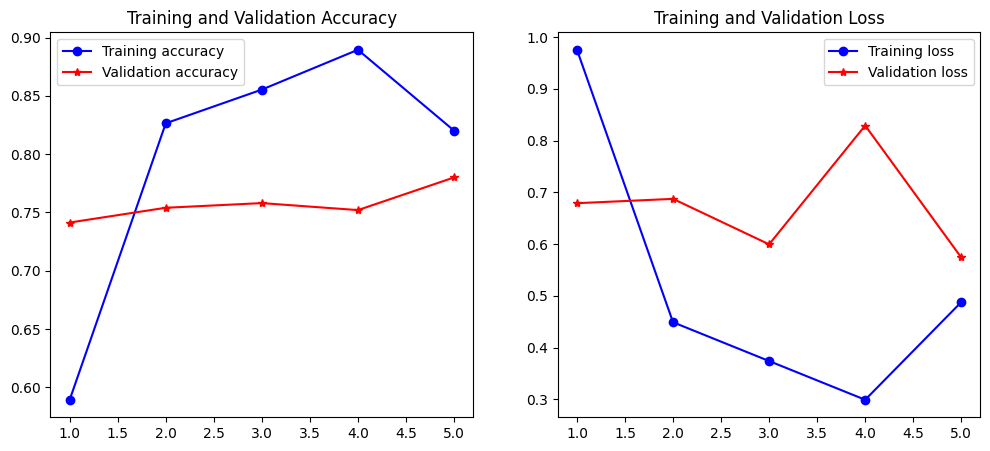

In [7]:
acc = history_scratch.history['accuracy']
val_acc = history_scratch.history['val_accuracy']
loss = history_scratch.history['loss']
val_loss = history_scratch.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

### Apply test 

In [8]:
test_loss, test_acc = model_scratch.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.8253 - loss: 0.3603
Test Accuracy: 0.8253333568572998


#### Save model

In [9]:
modelh5 = model_scratch
modelh5.save_weights("models/model.weights.h5")

#### load model

In [10]:
modelh5 = model_scratch
modelh5.load_weights("models/model.weights.h5")

#### Post preprocessing

In [11]:
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)      # (150,150,3)
    #model expect that shape (batch_size, height, width, channels)
    img_array = np.expand_dims(img_array, 0) # (1,150,150,3)   
    return img_array

#### Test Model 

In [28]:
class_names = {
    0: "Emerald",
    1: "Fake_Emerald",
    2: "Fake_Ruby",
    3: "Fake_Turquoise",
    4: "Ruby",
    5: "Turquoise"
}

img_path = r"Downlode-test-images\R.png"  # عدّل المسار

# Preprocess
x = preprocess_image(img_path)

# Prediction
predictions = modelh5.predict(x)


# Class index
predicted_class = predictions.argmax(axis=1)[0]
label = class_names[predicted_class]


print(f"Predicted label: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Predicted label: Turquoise
